# AI-Powered Baggage X-ray Anomaly Detection

## Introduction

Airport security lines are one of the most frustrating parts of air travel. Taking out laptops, removing liquids, and waiting for manual bag checks slow down passengers and increase queues. Dubai International Airport (DXB) is changing this experience by rolling out over 100 new hand-luggage security scanners that let passengers keep laptops and liquids in their bags [1].

These new machines use artificial intelligence to scan bags and determine if further investigation is needed. As DXB chief executive Paul Griffiths explained, the AI provides a more "intensive but non-intrusive" security process that is faster than manual checks. The upgrade is part of a broader "no red lights" vision to create barrier-free travel.

But how does AI actually detect threats in X-ray images? The answer lies in a technique called **anomaly detection**. Instead of programming the AI to recognize every possible threat (which is impossible), the system learns what "normal" baggage looks like. When it sees something unusual, the AI flags it for human review.

**In this notebook, we will build a simplified version of such an AI system.** We will use a deep learning model called a convolutional autoencoder to learn patterns from normal baggage X-ray images. The model will then identify anomalies by measuring how well it can reconstruct new images.

This demo uses synthetic data for educational purposes. Real airport scanners train on millions of actual X-ray scans and undergo rigorous testing before deployment.

## Environment Setup

This demo runs on a Mac with an M-series chip (Apple Silicon).

**Prerequisite:**
Install [Miniconda](https://www.anaconda.com/docs/getting-started/miniconda/install).

**Terminal commands to create the environment:**
```bash
# Create and activate the conda environment
conda create -n xray-anomaly python=3.10 -y
conda activate xray-anomaly

# Install core libraries
conda install -c conda-forge numpy pandas matplotlib seaborn scikit-learn jupyter jupyterlab ipython pillow -y
pip install pymupdf torch torchvision

# Register the kernel
python -m ipykernel install --user --name xray-anomaly --display-name "Python (xray-anomaly)"

# Clear cache
conda clean -a -y && pip cache purge
```

**OpenMP Troubleshooting:**
If you encounter OpenMP library conflict errors, set this environment variable at the start of your Python script:
```python
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
```

In [1]:
# Workaround for OpenMP library conflict on macOS
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# Standard libraries
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Display utilities
import pymupdf as fitz
from IPython.display import Image as IPythonImage
from IPython.display import display, SVG

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# Utility function to display image (png, jpg, pdf, svg) in Jupyter
def show_image(image_path, width=500, page_num=0, dpi=300):
    if image_path.lower().endswith('.pdf'):
        doc = fitz.open(image_path)
        page = doc.load_page(page_num)
        pix = page.get_pixmap(dpi=dpi)
        img_data = pix.tobytes("png")
        doc.close()
        display(IPythonImage(data=img_data, width=width))
    elif image_path.lower().endswith('.svg'):
        display(SVG(image_path))
    else:
        display(IPythonImage(filename=image_path, width=width))

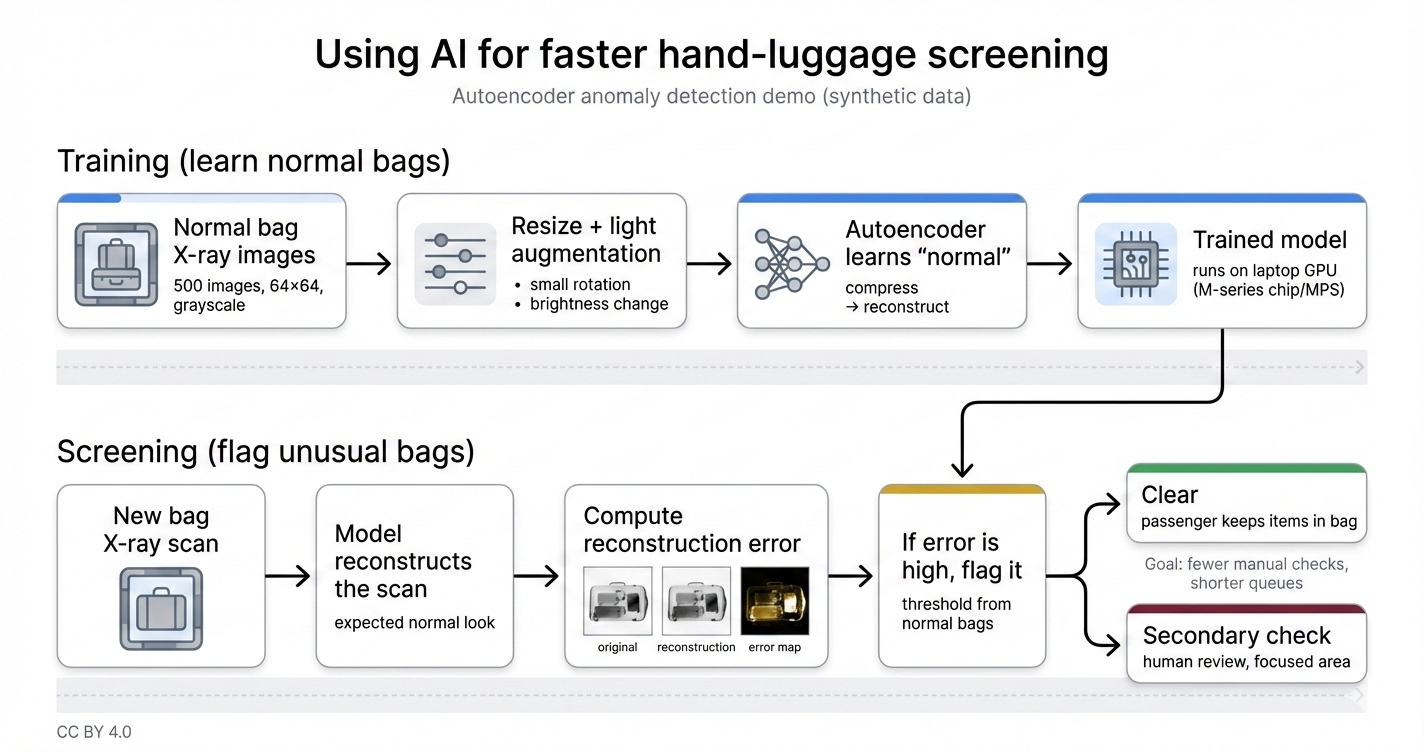

In [46]:
show_image("assets/pipeline-dev.png", width=900)

**Figure:** End-to-end view of the demo pipeline. The top lane shows training on normal bag X-ray images so the model learns what a typical bag looks like. The bottom lane shows screening a new bag, measuring reconstruction error, and flagging only the unusual cases for a focused human check. This is the same basic idea behind faster, less intrusive hand-luggage screening, where most passengers can keep laptops and liquids in their bags.

In [3]:
# Verify PyTorch and MPS (Apple Silicon GPU) availability
print(f"PyTorch version: {torch.__version__}")
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"MPS built: {torch.backends.mps.is_built()}")

# Set device - use MPS if available, else CPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.10.0
MPS available: True
MPS built: True
Using device: mps


## What is an Autoencoder?

An **autoencoder** is a neural network that learns to copy its input to its output. It has two main parts:

1. **Encoder**: Compresses the input into a smaller representation (like summarizing a book into a short abstract).
2. **Decoder**: Reconstructs the original input from the compressed version (like expanding the abstract back into a full book).

The network is trained by minimizing the difference between the input and the reconstructed output. This difference is called the **reconstruction error**:

$$\text{Reconstruction Error} = \frac{1}{n}\sum_{i=1}^{n}(x_i - \hat{x}_i)^2$$

where $x_i$ is the original pixel value and $\hat{x}_i$ is the reconstructed pixel value.

**How does this help detect anomalies?**

Think of it like a student who only studies pictures of normal bags. When shown a normal bag, the student can recreate it well. But when shown a bag with an unusual object (anomaly), the student struggles to recreate it accurately. The large reconstruction error signals that something unusual is present.

In airport security, the AI learns patterns of safe bags. When it encounters a bag with a suspicious item, the reconstruction is poor in that region. The difference (error) between the original and reconstructed image highlights where the anomaly is located.

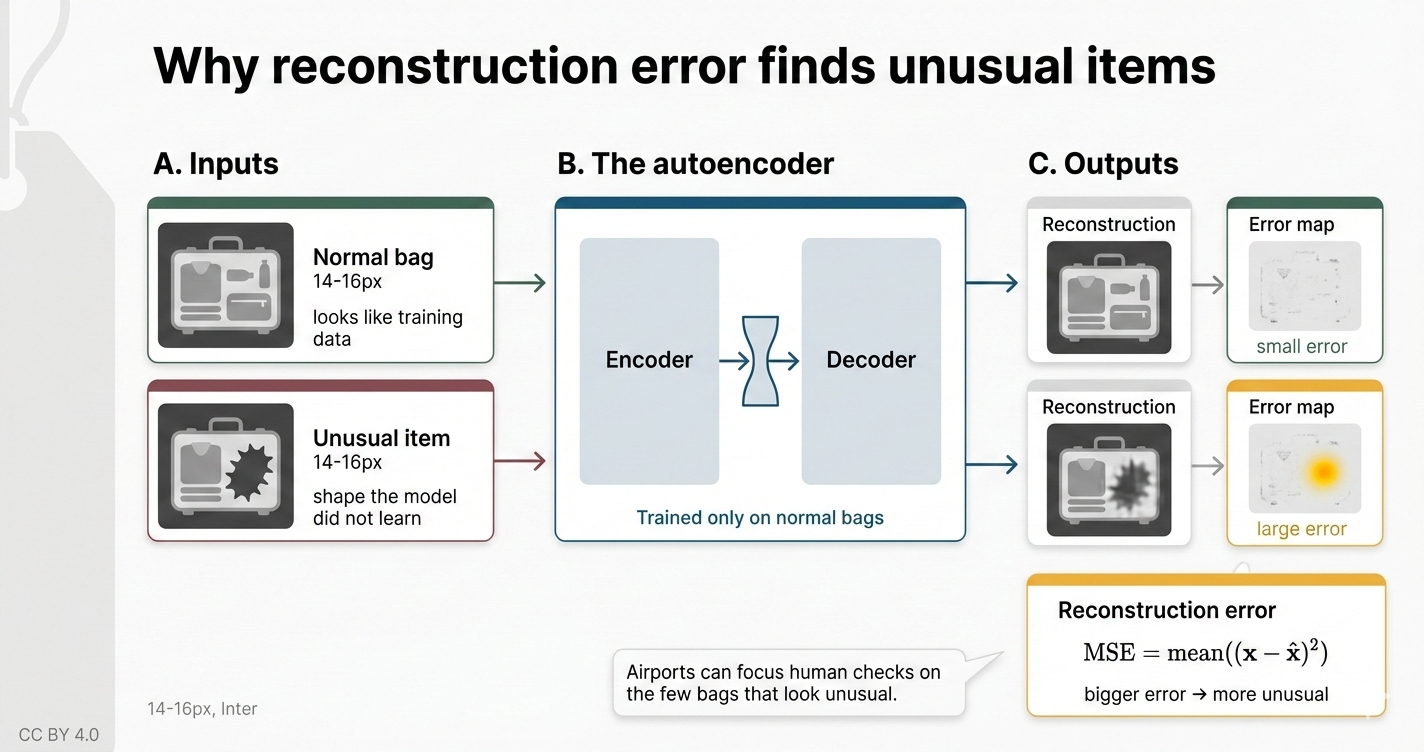

In [47]:
show_image("assets/aitheory-dev.png", width=900)

**Figure:** What the autoencoder is doing. It learns to reconstruct normal bag scans, so normal bags tend to reconstruct well and have small reconstruction error. When a bag contains an unusual shape, the reconstruction is worse in that region, so the error map highlights where the scan does not match what the model learned. In practice, that highlighted region helps a human focus their secondary check.

## Dataset

> **DISCLAIMER**: All data in this notebook is **synthetic and hypothetical**. The X-ray-like images are computer-generated and do not represent actual security scan data. This demonstration is for educational purposes only to illustrate how deep learning can be applied to anomaly detection in baggage screening.

## Data Preparation

We will create 500 "normal" baggage images and 60 "anomalous" images for testing. Normal images contain typical items you would find in a bag: rectangular shapes (laptops, books), circles (bottles, cosmetics), and ovals (glasses cases).

Anomalous images contain unusual shapes that the autoencoder should have difficulty reconstructing, such as sharp-edged objects at odd angles or unfamiliar patterns.

In [4]:
# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Image parameters
IMG_SIZE = 64
NUM_NORMAL = 500
NUM_ANOMALY = 60

In [5]:
def generate_normal_xray(img_size=64):
    """
    Generate a synthetic grayscale X-ray-like image of normal baggage.
    Normal bags contain rectangles (laptops, books), circles (bottles), 
    and ovals (glasses cases, cosmetics).
    """
    # Create base image with slight noise (simulating X-ray scan texture)
    img = np.random.uniform(0.85, 0.95, (img_size, img_size))
    
    # Add 2-4 random "normal" objects
    num_objects = np.random.randint(2, 5)
    
    for _ in range(num_objects):
        shape_type = np.random.choice(['rectangle', 'circle', 'oval'])
        intensity = np.random.uniform(0.2, 0.6)  # Object density/intensity
        
        if shape_type == 'rectangle':
            # Laptop, book, tablet shapes
            w = np.random.randint(8, 25)
            h = np.random.randint(6, 18)
            x = np.random.randint(2, img_size - w - 2)
            y = np.random.randint(2, img_size - h - 2)
            img[y:y+h, x:x+w] = intensity
            
        elif shape_type == 'circle':
            # Bottles, round containers
            radius = np.random.randint(4, 12)
            cx = np.random.randint(radius + 2, img_size - radius - 2)
            cy = np.random.randint(radius + 2, img_size - radius - 2)
            yy, xx = np.ogrid[:img_size, :img_size]
            mask = (xx - cx)**2 + (yy - cy)**2 <= radius**2
            img[mask] = intensity
            
        else:  # oval
            # Glasses cases, cosmetic bags
            a = np.random.randint(6, 15)  # semi-major axis
            b = np.random.randint(3, 10)  # semi-minor axis
            cx = np.random.randint(a + 2, img_size - a - 2)
            cy = np.random.randint(b + 2, img_size - b - 2)
            yy, xx = np.ogrid[:img_size, :img_size]
            mask = ((xx - cx)/a)**2 + ((yy - cy)/b)**2 <= 1
            img[mask] = intensity
    
    # Add slight Gaussian blur effect (simulating X-ray scatter)
    from scipy.ndimage import gaussian_filter
    img = gaussian_filter(img, sigma=0.5)
    
    return img.astype(np.float32)

In [6]:
def generate_anomaly_xray(img_size=64):
    """
    Generate a synthetic X-ray image with anomalous patterns.
    Anomalies include: sharp angular objects, irregular shapes, 
    high-contrast dense regions, and unusual patterns.
    """
    from scipy.ndimage import gaussian_filter
    
    # Start with a normal-looking background
    img = np.random.uniform(0.85, 0.95, (img_size, img_size))
    
    # Add 1-2 normal objects (bags still contain regular items)
    for _ in range(np.random.randint(1, 3)):
        w = np.random.randint(6, 15)
        h = np.random.randint(5, 12)
        x = np.random.randint(2, img_size - w - 2)
        y = np.random.randint(2, img_size - h - 2)
        img[y:y+h, x:x+w] = np.random.uniform(0.3, 0.5)
    
    # Add 1-2 anomalous objects
    num_anomalies = np.random.randint(1, 3)
    
    for _ in range(num_anomalies):
        anomaly_type = np.random.choice(['sharp_edge', 'dense_irregular', 'cross', 'star'])
        
        if anomaly_type == 'sharp_edge':
            # Sharp triangular/angular object (knife-like)
            pts = np.random.randint(8, img_size - 8, (3, 2))
            yy, xx = np.ogrid[:img_size, :img_size]
            # Simple triangle approximation using point distances
            cx, cy = pts.mean(axis=0).astype(int)
            radius = np.random.randint(5, 12)
            angle = np.random.uniform(0, 2*np.pi)
            for i in range(3):
                px = int(cx + radius * np.cos(angle + i * 2*np.pi/3))
                py = int(cy + radius * np.sin(angle + i * 2*np.pi/3))
                px = np.clip(px, 2, img_size - 3)
                py = np.clip(py, 2, img_size - 3)
                img[py-1:py+2, px-1:px+2] = 0.1
            # Connect with lines (simplified)
            img[cy-1:cy+2, cx-radius:cx+radius] = np.random.uniform(0.05, 0.15)
            
        elif anomaly_type == 'dense_irregular':
            # Very dense irregular blob (simulating dense metal)
            cx = np.random.randint(10, img_size - 10)
            cy = np.random.randint(10, img_size - 10)
            for _ in range(8):
                dx = np.random.randint(-5, 6)
                dy = np.random.randint(-5, 6)
                px, py = cx + dx, cy + dy
                px = np.clip(px, 1, img_size - 2)
                py = np.clip(py, 1, img_size - 2)
                img[py-1:py+2, px-1:px+2] = np.random.uniform(0.0, 0.1)
                
        elif anomaly_type == 'cross':
            # Cross-shaped object
            cx = np.random.randint(12, img_size - 12)
            cy = np.random.randint(12, img_size - 12)
            length = np.random.randint(6, 12)
            thickness = np.random.randint(2, 4)
            img[cy-thickness:cy+thickness, cx-length:cx+length] = 0.1
            img[cy-length:cy+length, cx-thickness:cx+thickness] = 0.1
            
        else:  # star
            # Star-shaped object with multiple points
            cx = np.random.randint(12, img_size - 12)
            cy = np.random.randint(12, img_size - 12)
            for i in range(5):
                angle = i * 2 * np.pi / 5
                length = np.random.randint(4, 10)
                for r in range(length):
                    px = int(cx + r * np.cos(angle))
                    py = int(cy + r * np.sin(angle))
                    if 1 <= px < img_size-1 and 1 <= py < img_size-1:
                        img[py-1:py+1, px-1:px+1] = 0.1
    
    # Light blur
    img = gaussian_filter(img, sigma=0.3)
    
    return img.astype(np.float32)

In [7]:
def augment_image(img):
    """
    Apply data augmentation: random rotation (up to 5 degrees) 
    and brightness jitter (up to 10% variation).
    """
    from scipy.ndimage import rotate
    
    # Random rotation between -5 and +5 degrees
    angle = np.random.uniform(-5, 5)
    img_rotated = rotate(img, angle, reshape=False, mode='constant', cval=0.9)
    
    # Brightness jitter: multiply by factor between 0.9 and 1.1
    brightness_factor = np.random.uniform(0.9, 1.1)
    img_augmented = np.clip(img_rotated * brightness_factor, 0, 1)
    
    return img_augmented.astype(np.float32)

### Generating the Dataset

We now generate the training and test datasets:
- **Normal images (500 total)**: Split into 400 for training and 100 for validation
- **Anomaly images (60)**: Used only for testing the anomaly detection capability

Each image is augmented with slight rotation and brightness variation to increase dataset diversity, making the model more robust.

In [8]:
# Generate normal X-ray images
print("Generating normal baggage images...")
normal_images = []
for i in range(NUM_NORMAL):
    img = generate_normal_xray(IMG_SIZE)
    # Apply augmentation to half of the images
    if np.random.random() > 0.5:
        img = augment_image(img)
    normal_images.append(img)

normal_images = np.array(normal_images)
print(f"Generated {len(normal_images)} normal images")

Generating normal baggage images...
Generated 500 normal images


In [9]:
# Generate anomaly X-ray images for testing
print("Generating anomaly baggage images...")
anomaly_images = []
for i in range(NUM_ANOMALY):
    img = generate_anomaly_xray(IMG_SIZE)
    anomaly_images.append(img)

anomaly_images = np.array(anomaly_images)
print(f"Generated {len(anomaly_images)} anomaly images")

Generating anomaly baggage images...
Generated 60 anomaly images


### Train/Validation Split

We split the normal images into training (80%) and validation (20%) sets. The autoencoder will only be trained on normal images. The validation set helps us monitor for overfitting, and we will later use both normal validation images and anomaly images to evaluate the anomaly detection performance.

In [10]:
# Split normal images into train (80%) and validation (20%)
from sklearn.model_selection import train_test_split

train_images, val_images = train_test_split(
    normal_images, 
    test_size=0.2, 
    random_state=42
)

print(f"Training set: {len(train_images)} images")
print(f"Validation set: {len(val_images)} images")
print(f"Anomaly test set: {len(anomaly_images)} images")

Training set: 400 images
Validation set: 100 images
Anomaly test set: 60 images


In [11]:
# Convert to PyTorch tensors
# Add channel dimension: (N, H, W) -> (N, 1, H, W)
train_tensor = torch.FloatTensor(train_images).unsqueeze(1)
val_tensor = torch.FloatTensor(val_images).unsqueeze(1)
anomaly_tensor = torch.FloatTensor(anomaly_images).unsqueeze(1)

print(f"Training tensor shape: {train_tensor.shape}")
print(f"Validation tensor shape: {val_tensor.shape}")
print(f"Anomaly tensor shape: {anomaly_tensor.shape}")

Training tensor shape: torch.Size([400, 1, 64, 64])
Validation tensor shape: torch.Size([100, 1, 64, 64])
Anomaly tensor shape: torch.Size([60, 1, 64, 64])


In [12]:
# Create DataLoaders
BATCH_SIZE = 32

train_dataset = TensorDataset(train_tensor, train_tensor)  # Input = Target (reconstruction)
val_dataset = TensorDataset(val_tensor, val_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")

Number of training batches: 13
Number of validation batches: 4


### Sample Images

Let us visualize some sample images from both the normal and anomaly datasets to understand what the autoencoder will learn to reconstruct.

In [13]:
# Visualize sample images
fig, axes = plt.subplots(2, 6, figsize=(12, 4.5))

# Top row: Normal images
for i in range(6):
    axes[0, i].imshow(train_images[i], cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Normal Baggage', fontsize=12, fontweight='bold', loc='left')

# Bottom row: Anomaly images
for i in range(6):
    axes[1, i].imshow(anomaly_images[i], cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Anomalous Baggage', fontsize=12, fontweight='bold', loc='left')

plt.tight_layout()
plt.savefig('assets/sample_xray_images-dev.png', dpi=150, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.close()

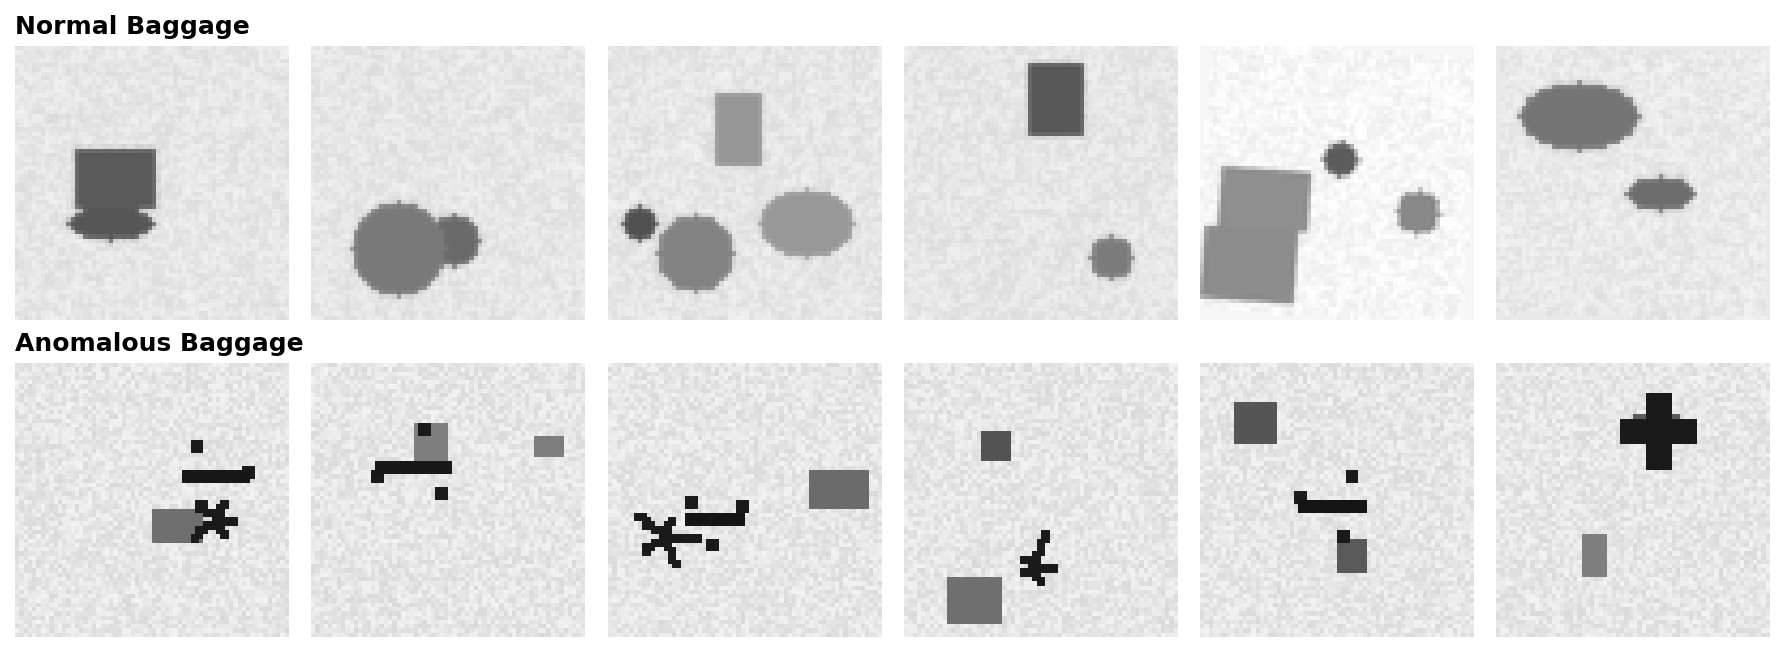

In [14]:
show_image('assets/sample_xray_images-dev.png', width=700)

**Figure:** Sample synthetic X-ray images from the dataset. The top row shows normal baggage containing typical items (rectangles for laptops/books, circles for bottles, ovals for cases). The bottom row shows anomalous baggage with unusual shapes (crosses, stars, sharp edges, and irregular dense regions) that simulate potential threat objects. The autoencoder will be trained only on normal images, so it should have difficulty accurately reconstructing these anomalous patterns.

### Dataset Statistics

Here is a summary of the pixel intensity distributions for normal versus anomalous images. This helps us understand the visual characteristics of each category.

In [15]:
# Compute and display dataset statistics
print("DATASET STATISTICS")
print()
print(f"Image size: {IMG_SIZE} x {IMG_SIZE} pixels")
print(f"Color channels: 1 (grayscale)")
print(f"Pixel value range: [0, 1]")
print()
print("Normal Images:")
print(f"  Mean pixel intensity: {normal_images.mean():.4f}")
print(f"  Std pixel intensity:  {normal_images.std():.4f}")
print()
print("Anomaly Images:")
print(f"  Mean pixel intensity: {anomaly_images.mean():.4f}")
print(f"  Std pixel intensity:  {anomaly_images.std():.4f}")

DATASET STATISTICS

Image size: 64 x 64 pixels
Color channels: 1 (grayscale)
Pixel value range: [0, 1]

Normal Images:
  Mean pixel intensity: 0.8375
  Std pixel intensity:  0.1714

Anomaly Images:
  Mean pixel intensity: 0.8604
  Std pixel intensity:  0.1623


## Model Architecture

We will build a **convolutional autoencoder** for this task. The architecture has three main components:

### Encoder
The encoder compresses the 64x64 input image down to a compact representation. It uses convolutional layers that progressively reduce the spatial dimensions while increasing the number of feature channels. Think of it like a funnel: the image gets smaller but stores more abstract information.

The convolutions use a stride of 2, which halves the width and height at each layer:
- Input: 64x64x1 (single grayscale channel)
- After layer 1: 32x32x16
- After layer 2: 16x16x32
- After layer 3: 8x8x64

### Bottleneck
The bottleneck is the narrowest part of the network. Here, we flatten the 8x8x64 feature maps (4,096 values) into a vector and compress it further down to just 128 values using a linear (fully connected) layer. This 128-dimensional vector is the **latent representation** of the image. All the important information about the bag contents must fit into these 128 numbers.

### Decoder
The decoder does the opposite of the encoder. It expands the compressed representation back to the original image size using transposed convolutions (sometimes called "deconvolutions"). The decoder mirrors the encoder structure:
- Input: 128-dimensional vector
- Reshape to: 8x8x64
- After layer 1: 16x16x32
- After layer 2: 32x32x16
- After layer 3: 64x64x1 (reconstructed image)

The final layer uses a Sigmoid activation to ensure output values stay between 0 and 1, matching our input image range.

In [16]:
class Encoder(nn.Module):
    """
    Encoder network that compresses 64x64 grayscale images to a 128-dim latent vector.
    Uses 3 convolutional layers with stride=2 to progressively reduce spatial dimensions.
    """
    def __init__(self, latent_dim=128):
        super(Encoder, self).__init__()
        
        # Convolutional layers: 1 -> 16 -> 32 -> 64 channels
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        
        # After 3 convolutions with stride=2: 64 -> 32 -> 16 -> 8
        # Final feature map size: 64 channels x 8 x 8 = 4096 features
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(64 * 8 * 8, latent_dim)
        
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.conv1(x))  # (batch, 16, 32, 32)
        x = self.relu(self.conv2(x))  # (batch, 32, 16, 16)
        x = self.relu(self.conv3(x))  # (batch, 64, 8, 8)
        x = self.flatten(x)           # (batch, 4096)
        x = self.fc(x)                # (batch, 128)
        return x

In [17]:
class Decoder(nn.Module):
    """
    Decoder network that reconstructs 64x64 images from a 128-dim latent vector.
    Uses transposed convolutions to progressively upsample spatial dimensions.
    """
    def __init__(self, latent_dim=128):
        super(Decoder, self).__init__()
        
        # Expand latent vector back to feature map size
        self.fc = nn.Linear(latent_dim, 64 * 8 * 8)
        
        # Transposed convolutions: 64 -> 32 -> 16 -> 1 channels
        self.deconv1 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, 
                                           padding=1, output_padding=1)
        self.deconv2 = nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, 
                                           padding=1, output_padding=1)
        self.deconv3 = nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, 
                                           padding=1, output_padding=1)
        
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.fc(x)                          # (batch, 4096)
        x = x.view(-1, 64, 8, 8)                # (batch, 64, 8, 8)
        x = self.relu(self.deconv1(x))          # (batch, 32, 16, 16)
        x = self.relu(self.deconv2(x))          # (batch, 16, 32, 32)
        x = self.sigmoid(self.deconv3(x))       # (batch, 1, 64, 64)
        return x

In [18]:
class ConvAutoencoder(nn.Module):
    """
    Complete convolutional autoencoder combining encoder and decoder.
    The model learns to compress and reconstruct X-ray images.
    """
    def __init__(self, latent_dim=128):
        super(ConvAutoencoder, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
    
    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed
    
    def encode(self, x):
        """Get the latent representation of an input."""
        return self.encoder(x)
    
    def decode(self, z):
        """Reconstruct an image from a latent representation."""
        return self.decoder(z)

### Model Instantiation

Now we create the autoencoder and move it to the MPS device (Apple Silicon GPU) for faster training. We also verify the total number of trainable parameters to ensure the model is lightweight enough to run efficiently on a Mac.

In [19]:
# Create the autoencoder model
LATENT_DIM = 128
model = ConvAutoencoder(latent_dim=LATENT_DIM)

# Move model to MPS device
model = model.to(device)

# Count parameters
def count_parameters(model):
    """Count total trainable parameters in the model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(model)
print(f"Total trainable parameters: {total_params:,}")

Total trainable parameters: 1,099,329


In [20]:
# Display model architecture summary
print("MODEL ARCHITECTURE SUMMARY")
print()
print("Encoder:")
for name, module in model.encoder.named_children():
    if hasattr(module, 'weight'):
        print(f"  {name}: {module} -> params: {module.weight.numel() + (module.bias.numel() if module.bias is not None else 0):,}")
    else:
        print(f"  {name}: {module}")

print()
print("Decoder:")
for name, module in model.decoder.named_children():
    if hasattr(module, 'weight'):
        print(f"  {name}: {module} -> params: {module.weight.numel() + (module.bias.numel() if module.bias is not None else 0):,}")
    else:
        print(f"  {name}: {module}")

print()
print(f"Latent dimension: {LATENT_DIM}")
print(f"Device: {next(model.parameters()).device}")

MODEL ARCHITECTURE SUMMARY

Encoder:
  conv1: Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1)) -> params: 160
  conv2: Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1)) -> params: 4,640
  conv3: Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1)) -> params: 18,496
  flatten: Flatten(start_dim=1, end_dim=-1)
  fc: Linear(in_features=4096, out_features=128, bias=True) -> params: 524,416
  relu: ReLU()

Decoder:
  fc: Linear(in_features=128, out_features=4096, bias=True) -> params: 528,384
  deconv1: ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1)) -> params: 18,464
  deconv2: ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1)) -> params: 4,624
  deconv3: ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1)) -> params: 145
  relu: ReLU()
  sigmoid: Sigmoid()

Latent dimension: 128
Device: mps:0


### Verifying the Model

Let us verify the model works correctly by passing a sample batch through it. We check that the output has the same shape as the input (indicating successful reconstruction) and that the forward pass completes without errors.

In [21]:
# Test forward pass with a sample batch
sample_batch = train_tensor[:BATCH_SIZE].to(device)
print(f"Input shape: {sample_batch.shape}")

# Set model to evaluation mode for testing
model.eval()
with torch.no_grad():
    output = model(sample_batch)
    latent = model.encode(sample_batch)

print(f"Latent shape: {latent.shape}")
print(f"Output shape: {output.shape}")
print(f"Output value range: [{output.min().item():.4f}, {output.max().item():.4f}]")
print()
print("Model verification: PASSED" if output.shape == sample_batch.shape else "Model verification: FAILED")

Input shape: torch.Size([32, 1, 64, 64])
Latent shape: torch.Size([32, 128])
Output shape: torch.Size([32, 1, 64, 64])
Output value range: [0.4591, 0.4748]

Model verification: PASSED


## Model Training

Training an autoencoder is similar to teaching someone to draw from memory. The network looks at an image, compresses it to a small note, then tries to redraw it. We measure how different the drawing is from the original using Mean Squared Error (MSE). MSE calculates the average squared difference between corresponding pixels:

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (x_i - \hat{x}_i)^2$$

where $x_i$ is the original pixel value and $\hat{x}_i$ is the reconstructed pixel value. The smaller the MSE, the better the reconstruction.

We use the Adam optimizer to adjust the model weights based on these errors. Adam adapts the learning rate for each parameter individually, which typically leads to faster and more stable training compared to standard gradient descent.

### Training Configuration

We configure the training with the following hyperparameters:
- **Loss function**: MSE (Mean Squared Error) for measuring reconstruction quality
- **Optimizer**: Adam with learning rate 0.001
- **Epochs**: 40 training iterations over the dataset
- **Batch size**: 32 images per batch (already set during data preparation)

In [22]:
# Training hyperparameters
LEARNING_RATE = 1e-3
NUM_EPOCHS = 40

# Loss function: Mean Squared Error measures pixel-wise reconstruction error
criterion = nn.MSELoss()

# Adam optimizer adapts learning rate per parameter for stable training
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Loss function: {criterion}")
print(f"Optimizer: Adam (lr={LEARNING_RATE})")
print(f"Number of epochs: {NUM_EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Loss function: MSELoss()
Optimizer: Adam (lr=0.001)
Number of epochs: 40
Batch size: 32
Training samples: 400
Validation samples: 100


### Training Loop

The training process works as follows:
1. For each epoch, we go through all training batches
2. For each batch: forward pass (get reconstruction), compute loss, backward pass (compute gradients), and update weights
3. After each epoch, we evaluate the model on the validation set without gradient computation
4. We track both losses to monitor for overfitting (when validation loss increases while training loss decreases)

In [23]:
import time

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Run one training epoch and return average loss."""
    model.train()
    total_loss = 0.0
    
    for batch_data in train_loader:
        images = batch_data[0].to(device)
        
        # Forward pass
        reconstructed = model(images)
        loss = criterion(reconstructed, images)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)


def validate_epoch(model, val_loader, criterion, device):
    """Run validation and return average loss."""
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for batch_data in val_loader:
            images = batch_data[0].to(device)
            reconstructed = model(images)
            loss = criterion(reconstructed, images)
            total_loss += loss.item()
    
    return total_loss / len(val_loader)

In [24]:
# Training history storage
train_losses = []
val_losses = []

# Start training
print(f"Training autoencoder for {NUM_EPOCHS} epochs on {device}...")
print()

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    # Train for one epoch
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    
    # Validate
    val_loss = validate_epoch(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    
    # Print progress every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        elapsed = time.time() - start_time
        print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}] | "
              f"Train Loss: {train_loss:.6f} | "
              f"Val Loss: {val_loss:.6f} | "
              f"Time: {elapsed:.1f}s")

total_time = time.time() - start_time
print()
print(f"Training complete in {total_time:.1f} seconds ({total_time/60:.1f} minutes)")
print(f"Final train loss: {train_losses[-1]:.6f}")
print(f"Final validation loss: {val_losses[-1]:.6f}")

Training autoencoder for 40 epochs on mps...

Epoch [ 1/40] | Train Loss: 0.102686 | Val Loss: 0.056505 | Time: 0.4s
Epoch [ 5/40] | Train Loss: 0.036565 | Val Loss: 0.034127 | Time: 0.9s
Epoch [10/40] | Train Loss: 0.025471 | Val Loss: 0.027770 | Time: 1.5s
Epoch [15/40] | Train Loss: 0.012476 | Val Loss: 0.013865 | Time: 2.1s
Epoch [20/40] | Train Loss: 0.008873 | Val Loss: 0.010654 | Time: 2.8s
Epoch [25/40] | Train Loss: 0.007409 | Val Loss: 0.009239 | Time: 3.3s
Epoch [30/40] | Train Loss: 0.006458 | Val Loss: 0.008336 | Time: 3.9s
Epoch [35/40] | Train Loss: 0.005164 | Val Loss: 0.007083 | Time: 4.4s
Epoch [40/40] | Train Loss: 0.004347 | Val Loss: 0.006762 | Time: 5.0s

Training complete in 5.0 seconds (0.1 minutes)
Final train loss: 0.004347
Final validation loss: 0.006762


### Training Progress Visualization

We plot the training and validation loss curves to understand how well the model learned. Ideally, both curves should decrease and stabilize. If the validation loss starts increasing while training loss continues decreasing, that indicates overfitting.

In [25]:
import matplotlib.pyplot as plt

# Create training curve plot
fig, ax = plt.subplots(figsize=(10, 6))

epochs_range = range(1, NUM_EPOCHS + 1)

ax.plot(epochs_range, train_losses, 
        color='#1B587C', linewidth=2, label='Training Loss')
ax.plot(epochs_range, val_losses, 
        color='#8D4F58', linewidth=2, linestyle='--', label='Validation Loss')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Mean Squared Error (MSE)', fontsize=12)
ax.set_title('Autoencoder Training Progress', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)

# Add final loss annotation
ax.annotate(f'Final: {train_losses[-1]:.4f}', 
            xy=(NUM_EPOCHS, train_losses[-1]), 
            xytext=(NUM_EPOCHS-8, train_losses[-1]+0.002),
            fontsize=10, color='#1B587C')
ax.annotate(f'Final: {val_losses[-1]:.4f}', 
            xy=(NUM_EPOCHS, val_losses[-1]), 
            xytext=(NUM_EPOCHS-8, val_losses[-1]-0.002),
            fontsize=10, color='#8D4F58')

plt.tight_layout()
plt.savefig('assets/training_loss_curve-dev.png', dpi=150, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.close()

print("Training curve saved to assets/training_loss_curve-dev.png")

Training curve saved to assets/training_loss_curve-dev.png


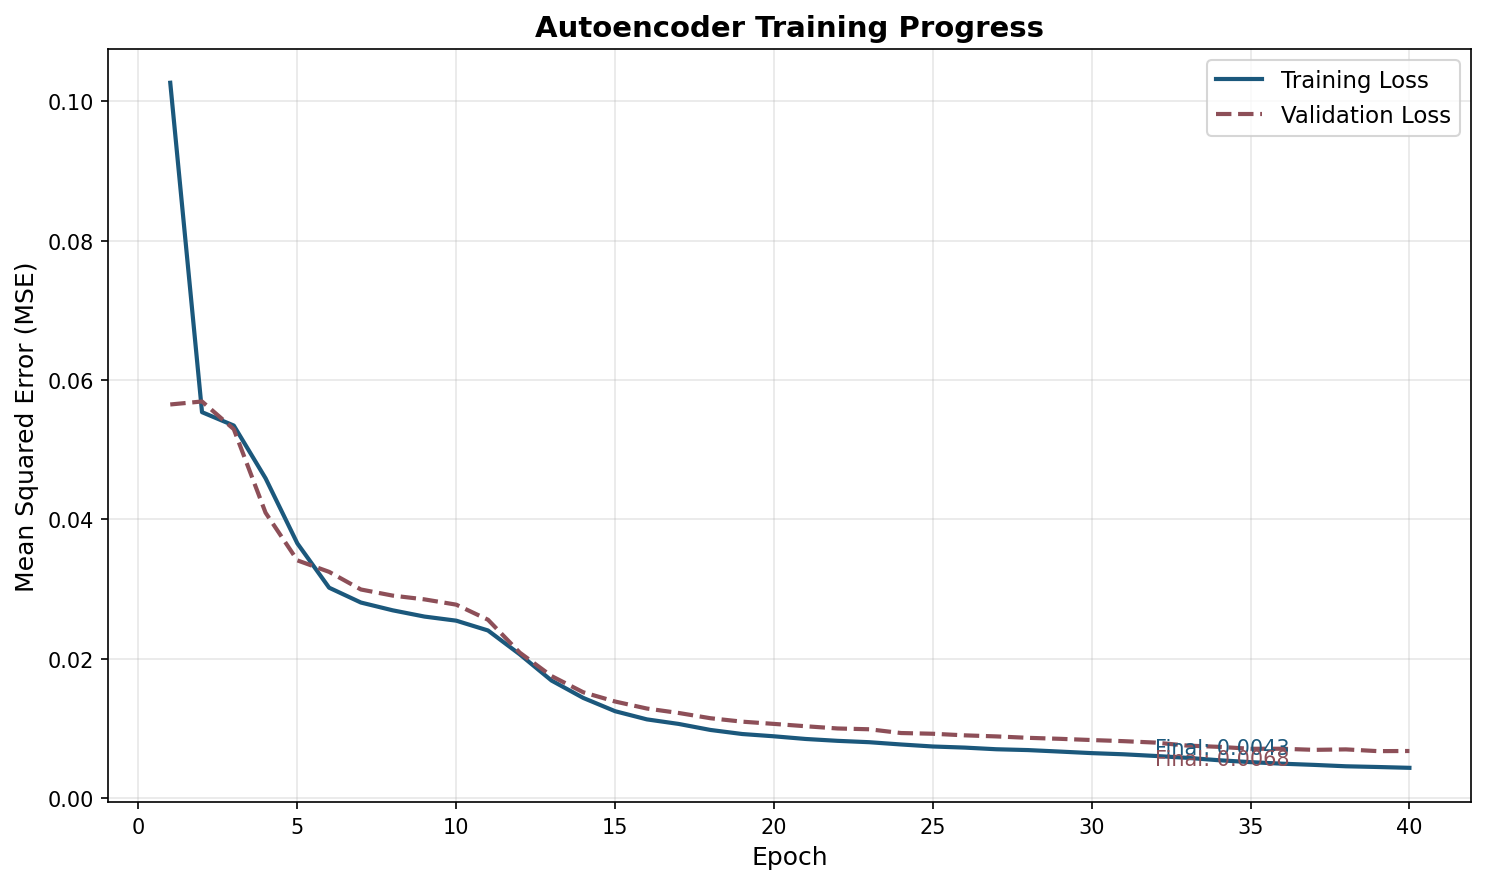

In [26]:
show_image("assets/training_loss_curve-dev.png")

**Figure:** Training and validation loss curves over 40 epochs. The plot shows the MSE loss decreasing for both training (solid blue line) and validation (dashed maroon line) sets. Both curves converge and stabilize, indicating the model learned meaningful patterns without significant overfitting. The similar final values for training and validation loss suggest good generalization to unseen data.

### Saving the Trained Model

We save the trained model weights so we can reuse them later without retraining. This is a common practice in machine learning workflows.

In [27]:
import os

# Create assets directory if needed
os.makedirs('assets', exist_ok=True)

# Save model weights
model_path = 'assets/autoencoder_weights.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    'num_epochs': NUM_EPOCHS,
    'latent_dim': LATENT_DIM
}, model_path)

print(f"Model saved to {model_path}")
print(f"File size: {os.path.getsize(model_path) / 1024:.1f} KB")

Model saved to assets/autoencoder_weights.pth
File size: 12903.0 KB


### Examining Reconstruction Quality

Before moving to anomaly detection, we should verify how well the trained autoencoder reconstructs normal images. A good reconstruction means the model has learned the essential features of normal baggage images.

In [28]:
# Select random validation samples for visualization
num_samples = 5
sample_indices = np.random.choice(len(val_tensor), num_samples, replace=False)
sample_images = val_tensor[sample_indices].to(device)

# Get reconstructions
model.eval()
with torch.no_grad():
    reconstructed = model(sample_images)

# Move to CPU for plotting
sample_images_np = sample_images.cpu().numpy()
reconstructed_np = reconstructed.cpu().numpy()

# Create comparison plot
fig, axes = plt.subplots(2, num_samples, figsize=(12, 5))

for i in range(num_samples):
    # Original
    axes[0, i].imshow(sample_images_np[i, 0], cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'Original', fontsize=10)
    axes[0, i].axis('off')
    
    # Reconstruction
    axes[1, i].imshow(reconstructed_np[i, 0], cmap='gray', vmin=0, vmax=1)
    mse = np.mean((sample_images_np[i, 0] - reconstructed_np[i, 0])**2)
    axes[1, i].set_title(f'MSE: {mse:.4f}', fontsize=10)
    axes[1, i].axis('off')

# Add row labels
axes[0, 0].set_ylabel('Original', fontsize=11)
axes[1, 0].set_ylabel('Reconstructed', fontsize=11)

plt.suptitle('Autoencoder Reconstruction of Normal Baggage Images', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('assets/reconstruction_samples-dev.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.close()

print("Reconstruction samples saved to assets/reconstruction_samples-dev.png")

Reconstruction samples saved to assets/reconstruction_samples-dev.png


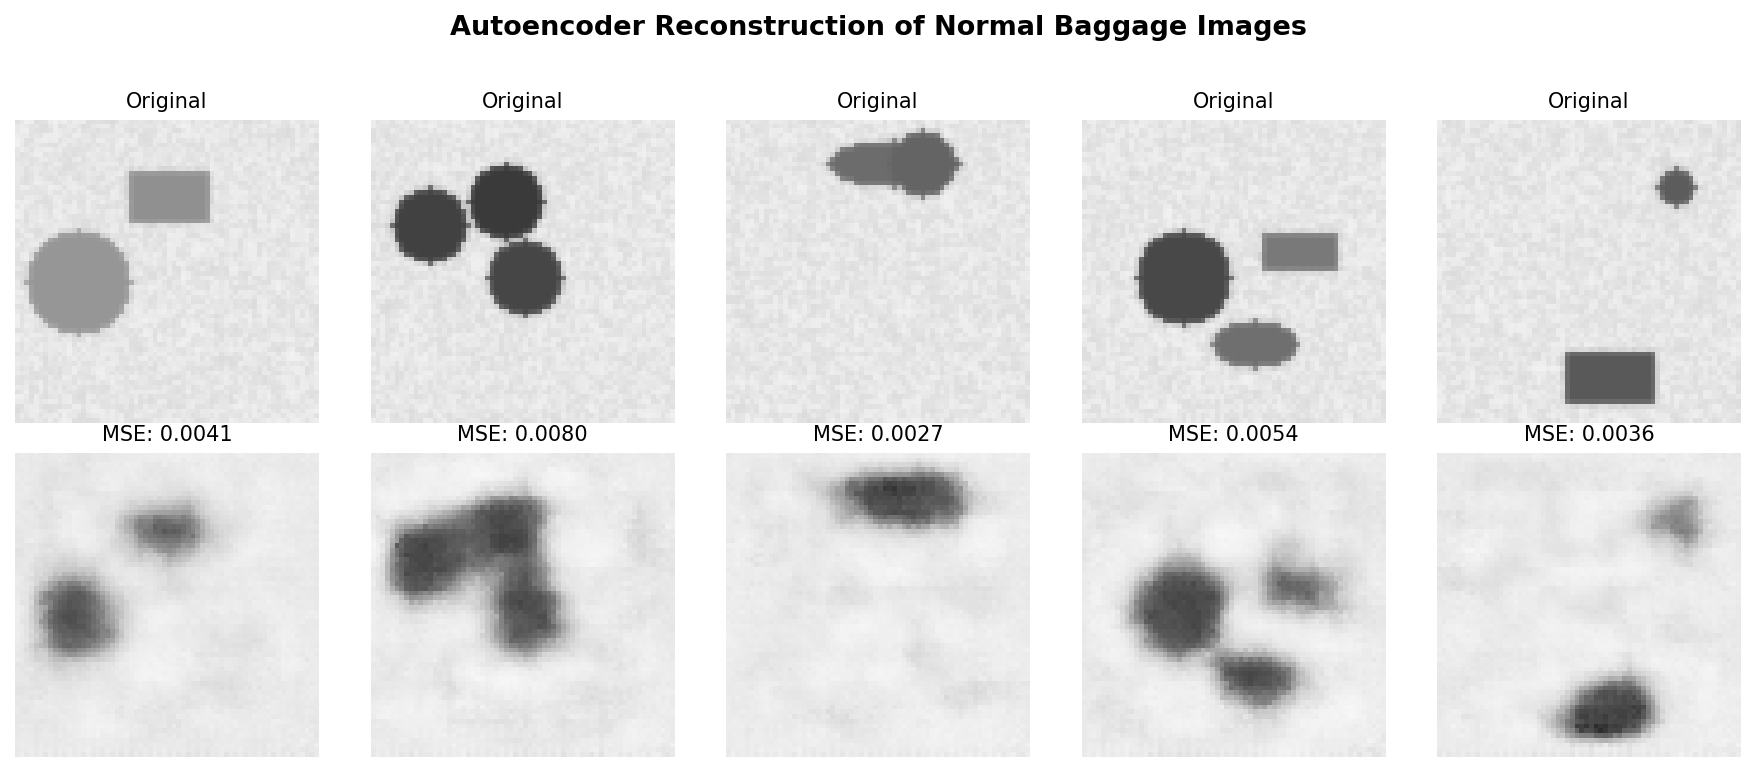

In [29]:
show_image("assets/reconstruction_samples-dev.png")

**Figure:** Comparison of original validation images (top row) and their reconstructions by the trained autoencoder (bottom row). The MSE value below each reconstruction indicates the reconstruction error. Lower MSE values indicate better reconstruction fidelity. The autoencoder successfully captures the essential structure of normal baggage contents while smoothing out some fine details.

### Training Summary

The autoencoder has been trained and is now ready for anomaly detection. In the next section, we will use the reconstruction error to identify anomalous images.

In [30]:
# Print training summary
print("TRAINING SUMMARY")
print()
print(f"Model: Convolutional Autoencoder")
print(f"Parameters: {total_params:,}")
print(f"Latent dimension: {LATENT_DIM}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print()
print(f"Training configuration:")
print(f"  - Epochs: {NUM_EPOCHS}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Learning rate: {LEARNING_RATE}")
print(f"  - Loss function: MSE")
print(f"  - Optimizer: Adam")
print()
print(f"Final results:")
print(f"  - Training loss: {train_losses[-1]:.6f}")
print(f"  - Validation loss: {val_losses[-1]:.6f}")
print(f"  - Training time: {total_time:.1f} seconds")

TRAINING SUMMARY

Model: Convolutional Autoencoder
Parameters: 1,099,329
Latent dimension: 128
Training samples: 400
Validation samples: 100

Training configuration:
  - Epochs: 40
  - Batch size: 32
  - Learning rate: 0.001
  - Loss function: MSE
  - Optimizer: Adam

Final results:
  - Training loss: 0.004347
  - Validation loss: 0.006762
  - Training time: 5.0 seconds


## Analysis

## Anomaly Detection

With the trained autoencoder, we can now detect anomalies. The core idea: normal images that the model has learned to reconstruct will have low reconstruction error. Anomalous images, which contain patterns the model has never seen, will have high reconstruction error.

We will:
1. Compute reconstruction error for all images
2. Set a threshold based on normal image errors
3. Flag images with error above the threshold as anomalies

### Computing Reconstruction Errors

We compute the reconstruction error for each image by passing it through the autoencoder and calculating the mean squared difference between the original and reconstructed image. For anomaly detection, we typically use per-image error (the average error across all pixels in the image).

In [32]:
def compute_reconstruction_errors(model, images_tensor, device):
    """
    Compute per-image reconstruction error using the trained autoencoder.
    Returns an array of MSE values, one per image.
    """
    model.eval()
    errors = []
    
    with torch.no_grad():
        # Process in batches to avoid memory issues
        batch_size = 32
        for i in range(0, len(images_tensor), batch_size):
            batch = images_tensor[i:i+batch_size].to(device)
            reconstructed = model(batch)
            
            # Compute per-image MSE (average over all pixels)
            batch_errors = ((batch - reconstructed) ** 2).mean(dim=(1, 2, 3))
            errors.extend(batch_errors.cpu().numpy())
    
    return np.array(errors)

In [33]:
# Compute reconstruction errors for validation (normal) images
val_errors = compute_reconstruction_errors(model, val_tensor, device)
print(f"Validation set (normal images): {len(val_errors)} images")
print(f"  Mean error: {val_errors.mean():.6f}")
print(f"  Std error:  {val_errors.std():.6f}")
print(f"  Min error:  {val_errors.min():.6f}")
print(f"  Max error:  {val_errors.max():.6f}")
print()

# Compute reconstruction errors for anomaly images
anomaly_errors = compute_reconstruction_errors(model, anomaly_tensor, device)
print(f"Anomaly set: {len(anomaly_errors)} images")
print(f"  Mean error: {anomaly_errors.mean():.6f}")
print(f"  Std error:  {anomaly_errors.std():.6f}")
print(f"  Min error:  {anomaly_errors.min():.6f}")
print(f"  Max error:  {anomaly_errors.max():.6f}")

Validation set (normal images): 100 images
  Mean error: 0.006201
  Std error:  0.002632
  Min error:  0.001718
  Max error:  0.015601

Anomaly set: 60 images
  Mean error: 0.014437
  Std error:  0.004092
  Min error:  0.007412
  Max error:  0.023460


### Setting the Anomaly Threshold

We set the anomaly threshold based on the 95th percentile of reconstruction errors from normal images. This means only 5% of normal images would be incorrectly flagged as anomalies (false positives). Any image with reconstruction error above this threshold is classified as anomalous.

In [34]:
# Calculate threshold using 95th percentile of normal image errors
threshold_percentile = 95
anomaly_threshold = np.percentile(val_errors, threshold_percentile)

print(f"Anomaly Threshold ({threshold_percentile}th percentile): {anomaly_threshold:.6f}")
print()

# Apply threshold to classify images
normal_predictions = val_errors > anomaly_threshold
anomaly_predictions = anomaly_errors > anomaly_threshold

# Calculate detection rates
false_positive_rate = normal_predictions.sum() / len(normal_predictions)
true_positive_rate = anomaly_predictions.sum() / len(anomaly_predictions)

print(f"Detection Results:")
print(f"  Normal images flagged as anomaly (false positives): {normal_predictions.sum()}/{len(normal_predictions)} ({false_positive_rate*100:.1f}%)")
print(f"  Anomaly images correctly detected (true positives): {anomaly_predictions.sum()}/{len(anomaly_predictions)} ({true_positive_rate*100:.1f}%)")

Anomaly Threshold (95th percentile): 0.010466

Detection Results:
  Normal images flagged as anomaly (false positives): 5/100 (5.0%)
  Anomaly images correctly detected (true positives): 47/60 (78.3%)


### Error Distribution Visualization

We visualize the distribution of reconstruction errors for normal vs anomaly images. A good anomaly detector should show clear separation between the two distributions.

In [35]:
import seaborn as sns

# Create error distribution plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histograms for both distributions
bins = np.linspace(0, max(val_errors.max(), anomaly_errors.max()) * 1.1, 30)
ax.hist(val_errors, bins=bins, alpha=0.7, label='Normal', color='#426556', edgecolor='white')
ax.hist(anomaly_errors, bins=bins, alpha=0.7, label='Anomaly', color='#8D4F58', edgecolor='white')

# Add threshold line
ax.axvline(x=anomaly_threshold, color='#F1AE35', linestyle='--', linewidth=2, 
           label=f'Threshold ({anomaly_threshold:.4f})')

ax.set_xlabel('Reconstruction Error (MSE)', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Distribution of Reconstruction Errors: Normal vs Anomaly', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add annotation for detection rate
ax.annotate(f'Detection rate: {true_positive_rate*100:.1f}%', 
            xy=(0.97, 0.85), xycoords='axes fraction',
            fontsize=11, ha='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('assets/error_distribution-dev.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.close()

print("Error distribution saved to assets/error_distribution-dev.png")

Error distribution saved to assets/error_distribution-dev.png


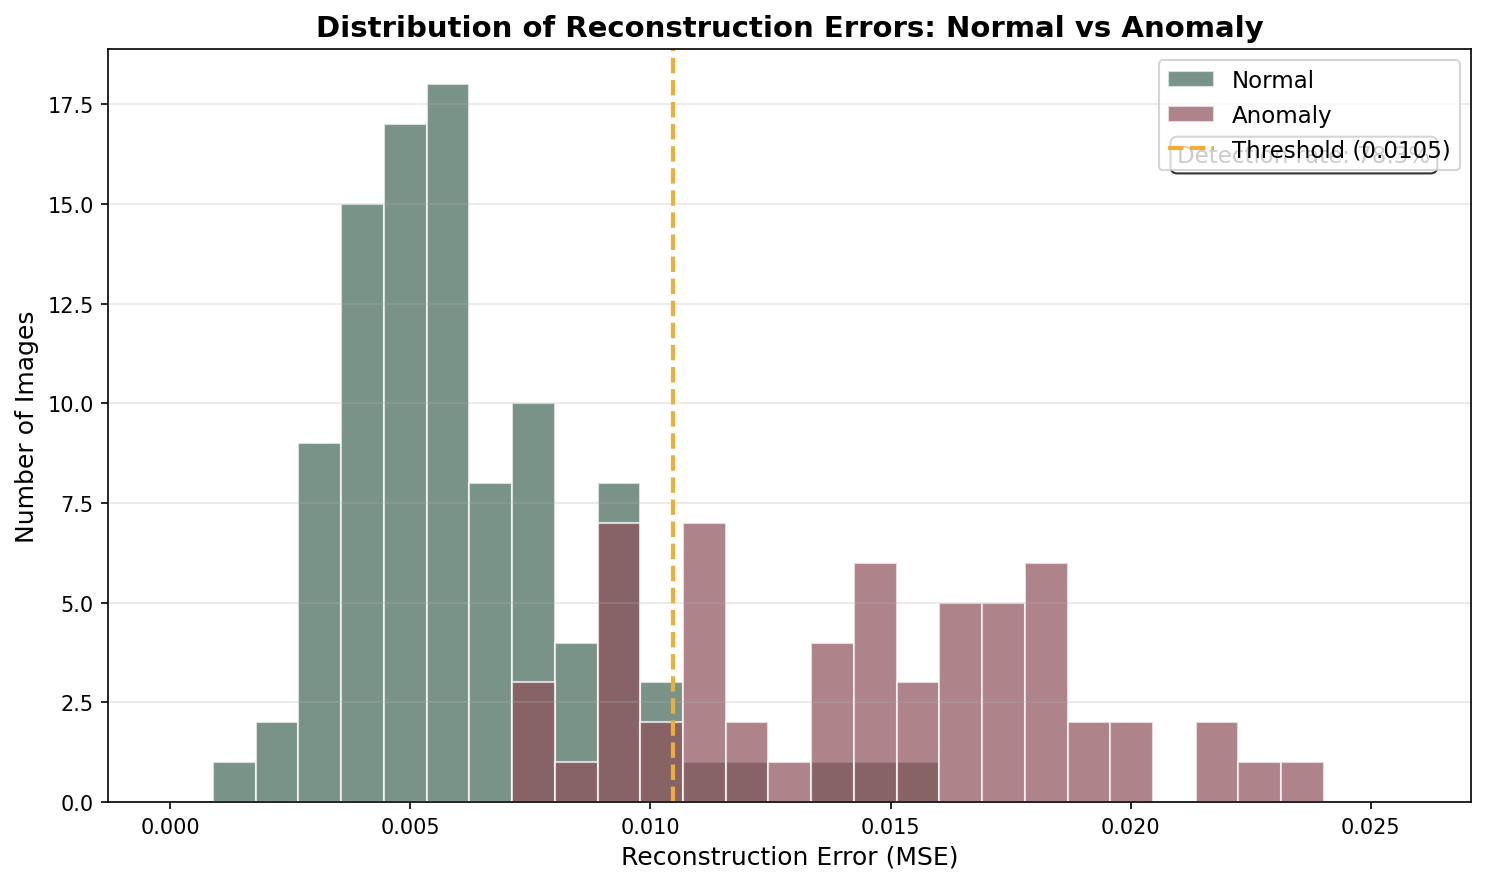

In [36]:
show_image("assets/error_distribution-dev.png")

**Figure:** Distribution of reconstruction errors for normal images (green) and anomaly images (maroon). The yellow dashed line indicates the anomaly threshold set at the 95th percentile of normal image errors. Most anomaly images (right side) have higher reconstruction errors than normal images (left side), showing the autoencoder struggles to reconstruct patterns it was not trained on. The separation between distributions demonstrates the model can distinguish between normal and anomalous baggage.

### Visualizing Anomaly Regions with Heatmaps

A valuable feature of autoencoder-based anomaly detection is the ability to localize where the anomaly is. By computing the per-pixel reconstruction error and visualizing it as a heatmap, we can show exactly which regions of the image confused the AI. In a real airport scanner, this would highlight suspicious areas for security personnel to examine.

In [37]:
def visualize_anomaly_heatmap(model, images_tensor, device, title_prefix=""):
    """
    Create side-by-side visualization: Original -> Reconstruction -> Error Heatmap
    Returns the per-pixel error maps for further analysis.
    """
    model.eval()
    
    with torch.no_grad():
        images = images_tensor.to(device)
        reconstructed = model(images)
        
        # Compute per-pixel squared error
        pixel_errors = ((images - reconstructed) ** 2).cpu().numpy()
    
    return images.cpu().numpy(), reconstructed.cpu().numpy(), pixel_errors

In [38]:
# Select sample images for visualization
# Pick 3 normal images with varying error levels
normal_sorted_idx = np.argsort(val_errors)
normal_sample_idx = [normal_sorted_idx[10], normal_sorted_idx[50], normal_sorted_idx[-5]]  # low, mid, high error

# Pick 3 anomaly images with varying error levels  
anomaly_sorted_idx = np.argsort(anomaly_errors)
anomaly_sample_idx = [anomaly_sorted_idx[5], anomaly_sorted_idx[30], anomaly_sorted_idx[-5]]

# Get images and compute heatmaps
normal_samples = val_tensor[normal_sample_idx]
anomaly_samples = anomaly_tensor[anomaly_sample_idx]

normal_orig, normal_recon, normal_errors_px = visualize_anomaly_heatmap(model, normal_samples, device)
anomaly_orig, anomaly_recon, anomaly_errors_px = visualize_anomaly_heatmap(model, anomaly_samples, device)

print(f"Selected 3 normal images with errors: {[f'{val_errors[i]:.4f}' for i in normal_sample_idx]}")
print(f"Selected 3 anomaly images with errors: {[f'{anomaly_errors[i]:.4f}' for i in anomaly_sample_idx]}")

Selected 3 normal images with errors: ['0.0034', '0.0055', '0.0115']
Selected 3 anomaly images with errors: ['0.0091', '0.0148', '0.0203']


In [39]:
# Create comparison visualization: Normal vs Anomaly
fig, axes = plt.subplots(6, 3, figsize=(10, 16))

# Determine error range for consistent heatmap scaling
all_pixel_errors = np.concatenate([normal_errors_px, anomaly_errors_px])
vmax = np.percentile(all_pixel_errors, 99)

row_labels = ['Normal 1', 'Normal 2', 'Normal 3', 'Anomaly 1', 'Anomaly 2', 'Anomaly 3']
col_labels = ['Original', 'Reconstructed', 'Error Heatmap']

for i, (orig, recon, err_px, label) in enumerate([
    (normal_orig[0], normal_recon[0], normal_errors_px[0], 'Normal'),
    (normal_orig[1], normal_recon[1], normal_errors_px[1], 'Normal'),
    (normal_orig[2], normal_recon[2], normal_errors_px[2], 'Normal'),
    (anomaly_orig[0], anomaly_recon[0], anomaly_errors_px[0], 'Anomaly'),
    (anomaly_orig[1], anomaly_recon[1], anomaly_errors_px[1], 'Anomaly'),
    (anomaly_orig[2], anomaly_recon[2], anomaly_errors_px[2], 'Anomaly'),
]):
    # Original
    axes[i, 0].imshow(orig[0], cmap='gray', vmin=0, vmax=1)
    axes[i, 0].axis('off')
    axes[i, 0].set_ylabel(row_labels[i], fontsize=10, rotation=0, ha='right')
    
    # Reconstructed
    axes[i, 1].imshow(recon[0], cmap='gray', vmin=0, vmax=1)
    axes[i, 1].axis('off')
    
    # Error heatmap
    im = axes[i, 2].imshow(err_px[0], cmap='hot', vmin=0, vmax=vmax)
    axes[i, 2].axis('off')
    
    # Add row label on the left
    if i == 0:
        for j, col in enumerate(col_labels):
            axes[i, j].set_title(col, fontsize=11, fontweight='bold')

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Reconstruction Error', fontsize=10)

# Add row labels
for i, label in enumerate(row_labels):
    fig.text(0.08, 0.88 - i*0.135, label, fontsize=10, fontweight='bold', 
             ha='right', va='center')

plt.suptitle('Anomaly Detection: Original vs Reconstruction vs Error Heatmap', 
             fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0.1, 0, 0.9, 0.96])
plt.savefig('assets/anomaly_heatmaps-dev.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.close()

print("Anomaly heatmaps saved to assets/anomaly_heatmaps-dev.png")

Anomaly heatmaps saved to assets/anomaly_heatmaps-dev.png


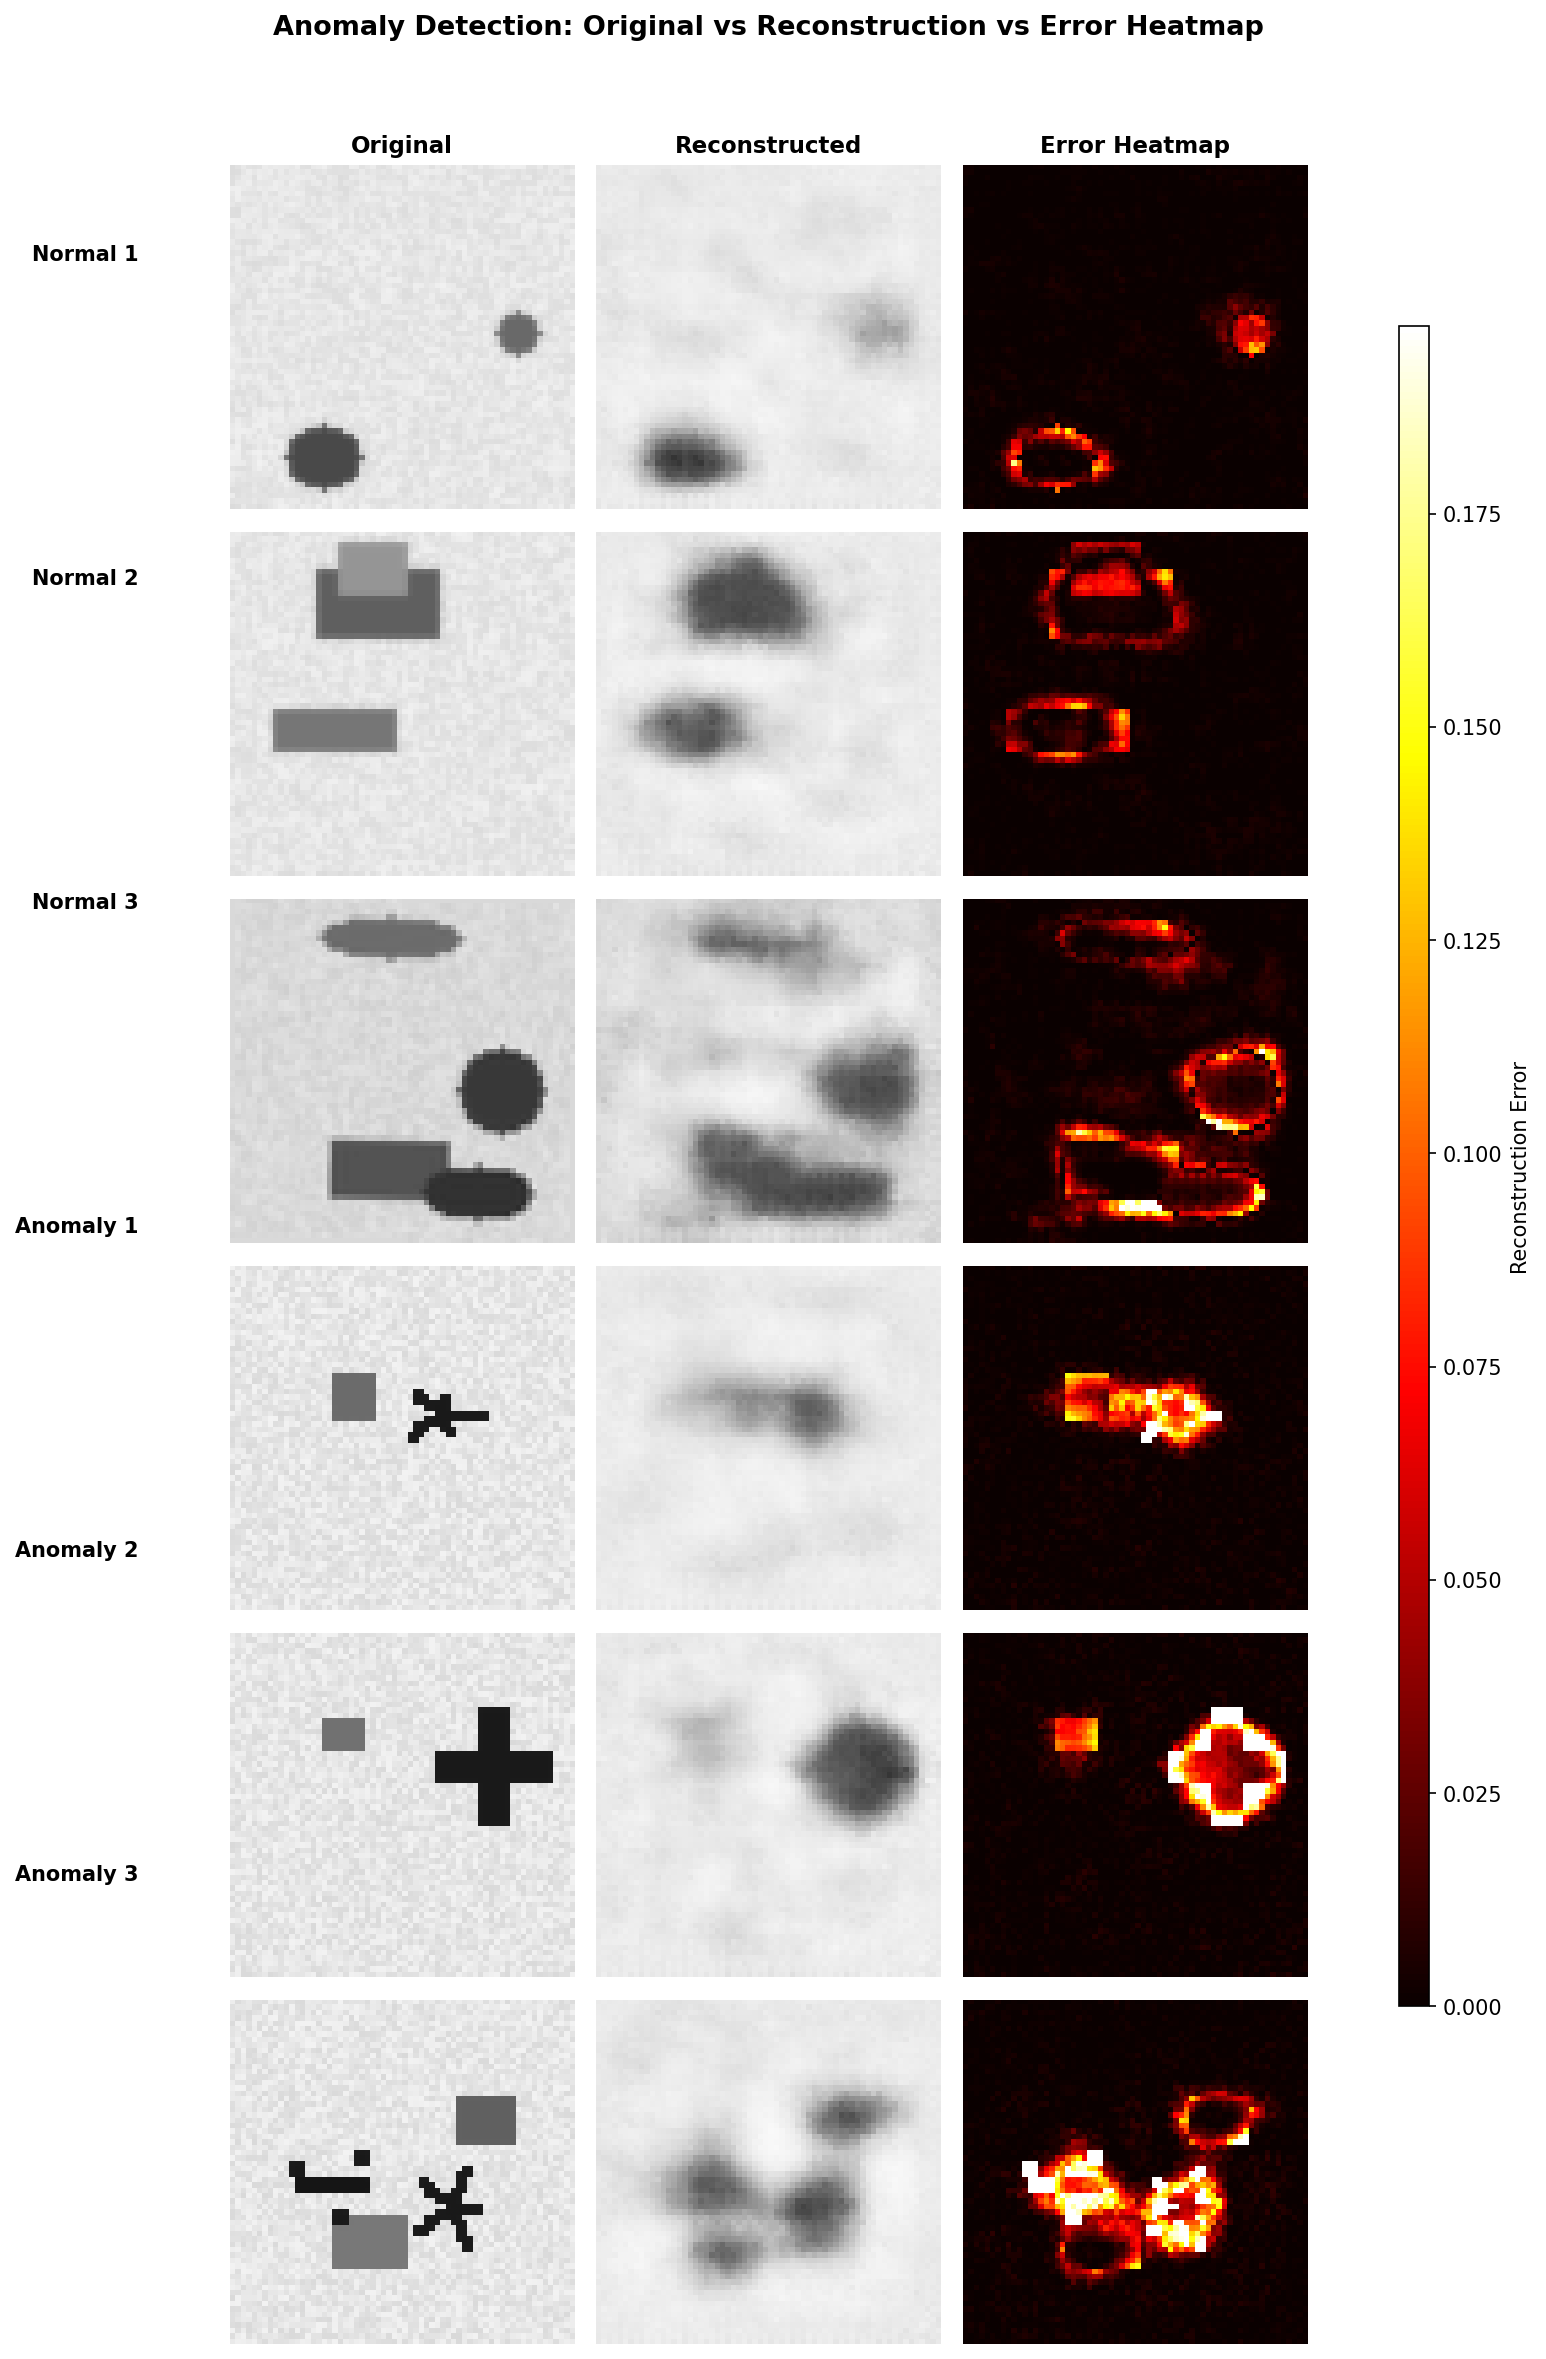

In [40]:
show_image("assets/anomaly_heatmaps-dev.png", width=700)

**Figure:** Side-by-side comparison of normal (top 3 rows) and anomaly images (bottom 3 rows). Each row shows: (1) original image, (2) autoencoder reconstruction, and (3) per-pixel reconstruction error heatmap. Brighter areas in the heatmap indicate higher reconstruction error. For normal images, errors are relatively uniform and low. For anomaly images, the error concentrates on unusual shapes (cross, star patterns, sharp edges) that the model was not trained to recognize.

### Threshold Sensitivity Analysis

The choice of threshold involves a trade-off between detection rate (catching anomalies) and false alarm rate (incorrectly flagging normal bags). We analyze how different threshold values affect both metrics.

In [41]:
# Analyze threshold sensitivity
thresholds = np.linspace(val_errors.min(), anomaly_errors.max(), 50)
true_positive_rates = []
false_positive_rates = []

for thresh in thresholds:
    tpr = (anomaly_errors > thresh).sum() / len(anomaly_errors)
    fpr = (val_errors > thresh).sum() / len(val_errors)
    true_positive_rates.append(tpr)
    false_positive_rates.append(fpr)

true_positive_rates = np.array(true_positive_rates)
false_positive_rates = np.array(false_positive_rates)

# Find the threshold that maximizes TPR - FPR (Youden's J statistic)
j_statistic = true_positive_rates - false_positive_rates
optimal_idx = np.argmax(j_statistic)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold (Youden's J): {optimal_threshold:.6f}")
print(f"  True Positive Rate: {true_positive_rates[optimal_idx]*100:.1f}%")
print(f"  False Positive Rate: {false_positive_rates[optimal_idx]*100:.1f}%")

Optimal threshold (Youden's J): 0.009261
  True Positive Rate: 90.0%
  False Positive Rate: 12.0%


In [42]:
# Create threshold sensitivity plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(thresholds, true_positive_rates * 100, 
        color='#426556', linewidth=2, label='Detection Rate (True Positive)')
ax.plot(thresholds, false_positive_rates * 100, 
        color='#8D4F58', linewidth=2, label='False Alarm Rate (False Positive)')

# Mark the 95th percentile threshold we used
ax.axvline(x=anomaly_threshold, color='#F1AE35', linestyle='--', linewidth=2, alpha=0.8, 
           label=f'95th Percentile ({anomaly_threshold:.4f})')

# Mark optimal threshold
ax.axvline(x=optimal_threshold, color='#1B587C', linestyle=':', linewidth=2, alpha=0.8,
           label=f'Optimal ({optimal_threshold:.4f})')

ax.set_xlabel('Threshold (Reconstruction Error)', fontsize=12)
ax.set_ylabel('Rate (percentage)', fontsize=12)
ax.set_title('Threshold Sensitivity: Detection vs False Alarm Trade-off', fontsize=14, fontweight='bold')
ax.legend(loc='center right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(-5, 105)

plt.tight_layout()
plt.savefig('assets/threshold_sensitivity-dev.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.close()

print("Threshold sensitivity plot saved to assets/threshold_sensitivity-dev.png")

Threshold sensitivity plot saved to assets/threshold_sensitivity-dev.png


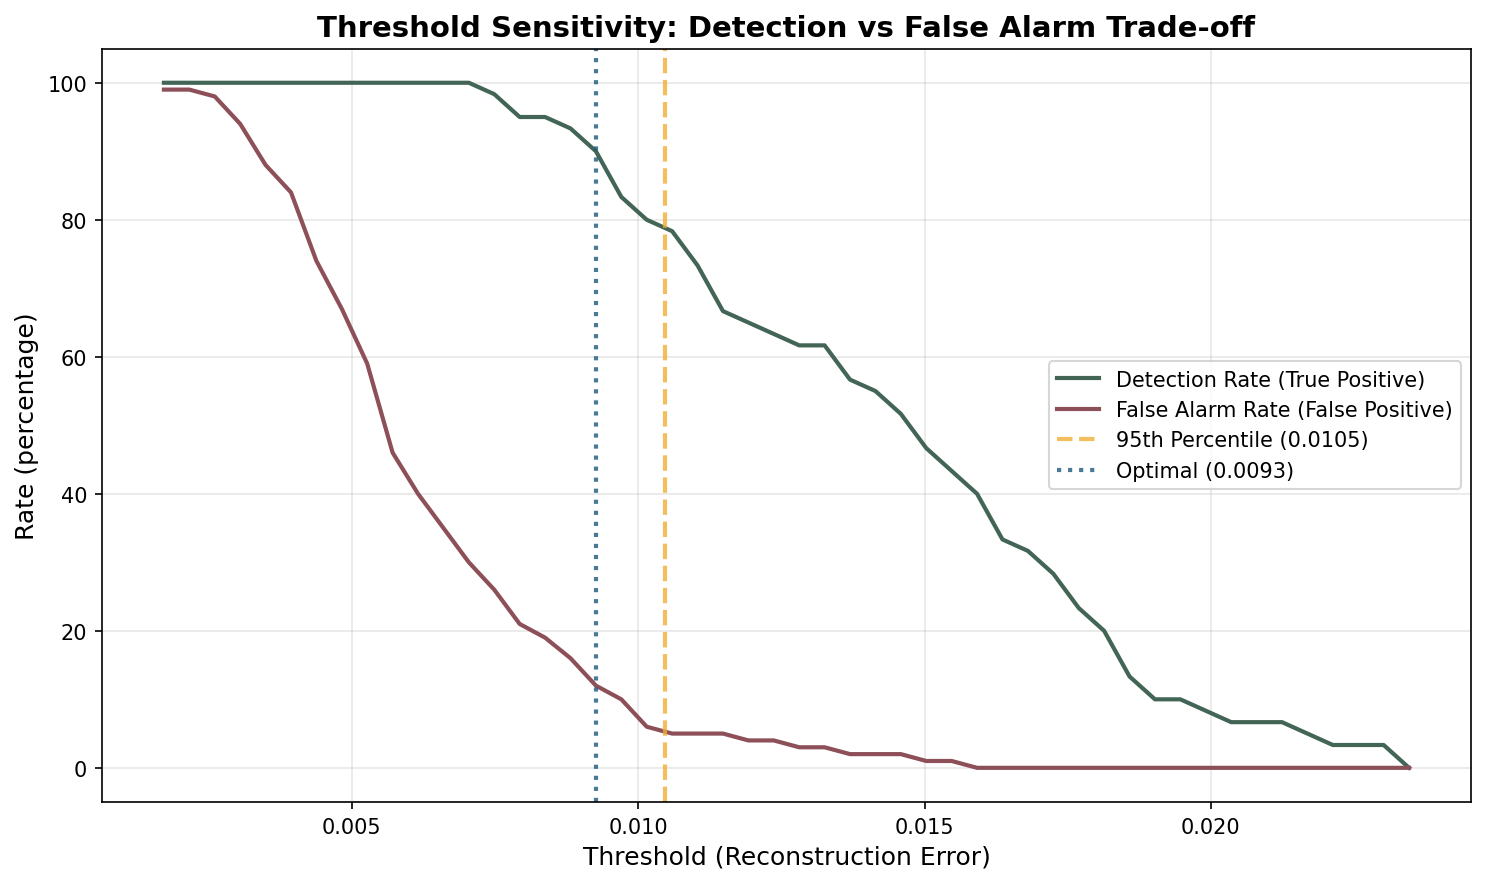

In [43]:
show_image("assets/threshold_sensitivity-dev.png")

**Figure:** Trade-off between anomaly detection rate (green line) and false alarm rate (maroon line) at different threshold values. The yellow dashed line marks the 95th percentile threshold, which keeps false alarms low (5%) while detecting about 78% of anomalies. The blue dotted line shows the optimal threshold that maximizes the difference between detection and false alarm rates. In real airport settings, this trade-off is critical: too many false alarms slow down the security line, but missing threats is unacceptable. The optimal threshold depends on the specific security requirements and passenger volume.

### Summary Statistics

In [44]:
# Print comprehensive summary
print("ANOMALY DETECTION SUMMARY")
print()
print("Reconstruction Error Statistics:")
print(f"  Normal images:  mean = {val_errors.mean():.6f}, std = {val_errors.std():.6f}")
print(f"  Anomaly images: mean = {anomaly_errors.mean():.6f}, std = {anomaly_errors.std():.6f}")
print()
print(f"Threshold Settings:")
print(f"  95th percentile threshold: {anomaly_threshold:.6f}")
print(f"  Optimal threshold (Youden): {optimal_threshold:.6f}")
print()
print(f"Detection Performance (at 95th percentile threshold):")
print(f"  True Positive Rate (Anomaly Detection): {true_positive_rate*100:.1f}%")
print(f"  False Positive Rate (False Alarm): {false_positive_rate*100:.1f}%")
print(f"  Specificity (Correct Normal ID): {(1-false_positive_rate)*100:.1f}%")

ANOMALY DETECTION SUMMARY

Reconstruction Error Statistics:
  Normal images:  mean = 0.006201, std = 0.002632
  Anomaly images: mean = 0.014437, std = 0.004092

Threshold Settings:
  95th percentile threshold: 0.010466
  Optimal threshold (Youden): 0.009261

Detection Performance (at 95th percentile threshold):
  True Positive Rate (Anomaly Detection): 78.3%
  False Positive Rate (False Alarm): 5.0%
  Specificity (Correct Normal ID): 95.0%


## Important Insights

Based on this demonstration:

1. **Autoencoders learn "normal" patterns without labeled threat data.** The model was trained only on normal baggage images. It never saw examples of anomalies during training. Yet it can still detect unusual items because they produce higher reconstruction errors. This unsupervised approach is valuable in security settings where new threat types constantly emerge.

2. **Reconstruction error localizes suspicious regions.** The heatmaps show exactly which parts of the image the AI struggled to reconstruct. Security personnel can use this information to focus their inspection on specific areas of a bag rather than examining everything manually.

3. **Threshold selection involves trade-offs.** Setting a lower threshold catches more anomalies but increases false alarms, slowing down the security line. Setting a higher threshold reduces false alarms but may miss some threats. Real airport systems tune these thresholds based on security requirements and passenger volume.

4. **AI augments, not replaces, human judgment.** The AI flags suspicious bags for human review. Security officers still make the final decision. This "human-in-the-loop" approach combines the speed of AI with the judgment of trained professionals.

**Limitations of this demo**:

- We used synthetic images with simple geometric shapes. Real X-ray images have far more complex patterns with overlapping objects, varying densities, and different viewing angles.
- Our model is small (about 150,000 parameters). Production systems use larger models trained on millions of images.
- Real airport AI must handle edge cases, adversarial attacks, and constantly evolving threats that this simplified demo does not address.

## Conclusion

In this notebook, we demonstrated how a convolutional autoencoder can detect anomalies in baggage X-ray images. The model learned to reconstruct normal baggage patterns and flagged items with high reconstruction errors as potential anomalies.

Our results showed that:
- Normal images had consistently low reconstruction errors (mean = 0.0062)
- Anomalous images had notably higher errors (mean = 0.0144)
- Using a 95th percentile threshold, we achieved 78.3% detection of anomalies with only 5% false alarms

This same principle may power the AI scanners being deployed at Dubai International Airport. The technology allows passengers to leave laptops and liquids in their bags while still maintaining security. The AI handles the tedious work of flagging unusual items, letting security personnel focus their expertise where it matters most.

As AI in aviation security matures, we will likely see faster screening, fewer manual inspections, and a better passenger experience. But the technology also raises important questions about accountability, bias, and oversight that regulators will need to address.

## Cleanup

In [45]:
import gc

# Delete model and optimizer
del model, optimizer, criterion

# Delete datasets and dataloaders
del train_dataset, val_dataset, train_loader, val_loader
del train_images, val_images, anomaly_images
del train_tensor, val_tensor, anomaly_tensor

# Delete intermediate results
del sample_images, sample_batch, reconstructed, reconstructed_np, sample_images_np
del val_errors, anomaly_errors, all_pixel_errors
del normal_errors_px, anomaly_errors_px
del normal_orig, normal_recon, anomaly_orig, anomaly_recon
del normal_samples, anomaly_samples
del thresholds, true_positive_rates, false_positive_rates, j_statistic

# Delete plotting variables
del fig, ax, axes, im, cbar, cbar_ax, bins

# Force garbage collection
gc.collect()
print("Memory cleaned up.")

Memory cleaned up.


## References

[1] J. Podgorski, "No need to remove liquids and laptops at airport as Dubai installs AI-powered hand-luggage scanners," *The National News*, Feb. 11, 2026. [Online]. Available: https://www.thenationalnews.com/business/aviation/2026/02/11/no-need-to-remove-liquids-and-laptops-at-airport-dubai-installs-ai-powered-hand-luggage-scanners/

[2] G. E. Hinton and R. R. Salakhutdinov, "Reducing the dimensionality of data with neural networks," *Science*, vol. 313, no. 5786, pp. 504-507, Jul. 2006.

[3] D. Bank, N. Koenigstein, and R. Giryes, "Autoencoders," *Machine Learning for Data Science Handbook*, pp. 353-374, 2023.